<a href="https://colab.research.google.com/github/Madathanapalleleena/DL_exploration/blob/main/dl_final_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
navoneel_brain_mri_images_for_brain_tumor_detection_path = kagglehub.dataset_download('navoneel/brain-mri-images-for-brain-tumor-detection')

print('Data source import complete.')


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

print("Folders:", os.listdir(dataset_path))

Folders: ['no', 'yes']


Access dataset in code

In [ ]:
classes = os.listdir(dataset_path)

for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, ":", len(os.listdir(path)))

no : 98
yes : 155


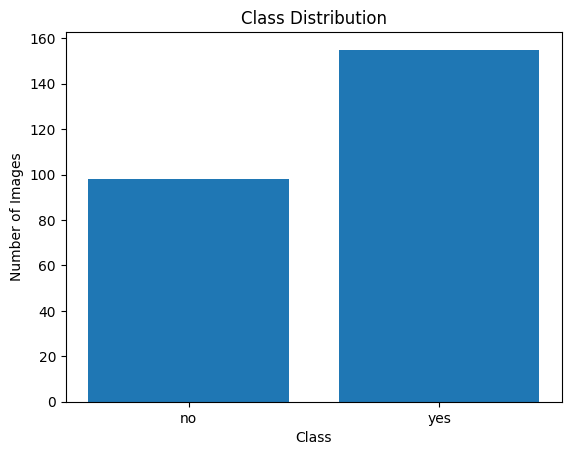

In [ ]:
counts = [len(os.listdir(os.path.join(dataset_path, c))) for c in classes]

plt.figure()
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

**Verify dataset is loaded correctly**

See differences between classes

Debug image issues

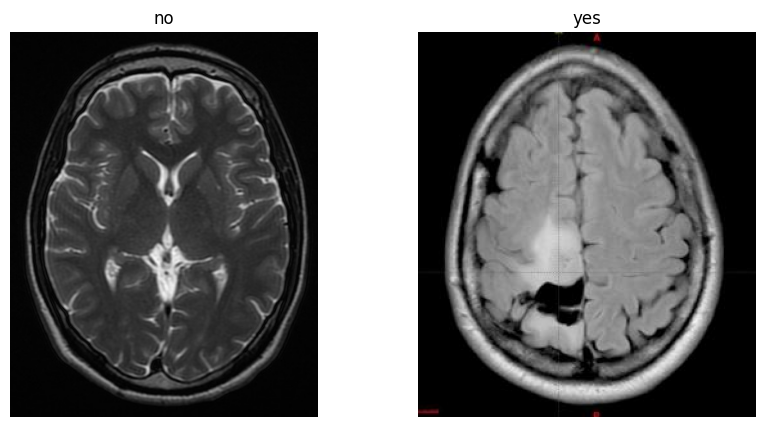

In [ ]:
plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))
    img_path = os.path.join(dataset_path, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis("off")

plt.show()

This code loads up to 50 images from each class, **collects their dimensions (width, height)**, and prints all unique image sizes in the dataset to check if they are consistent or vary.

In [ ]:
shapes = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder, img_name))
        shapes.append(img.size)

print("Unique image sizes:", set(shapes))

Unique image sizes: {(300, 325), (311, 355), (420, 280), (283, 357), (189, 173), (393, 400), (278, 324), (1061, 1280), (728, 725), (1059, 1200), (200, 252), (201, 251), (380, 530), (321, 352), (441, 442), (276, 338), (356, 474), (197, 255), (294, 380), (283, 334), (150, 198), (213, 236), (227, 262), (224, 245), (210, 264), (207, 243), (355, 450), (223, 303), (442, 454), (232, 217), (504, 630), (456, 519), (472, 537), (273, 318), (276, 326), (310, 355), (467, 586), (359, 449), (201, 250), (192, 192), (225, 225), (254, 325), (310, 366), (216, 234), (218, 231), (680, 680), (289, 300), (200, 210), (214, 236), (450, 446), (442, 442), (197, 256), (310, 380), (825, 993), (300, 168), (249, 269), (314, 340), (228, 221), (318, 380), (400, 431), (526, 555), (260, 298), (200, 253), (300, 200), (630, 630), (400, 442), (250, 290), (512, 512), (630, 614), (248, 338), (215, 234), (276, 323), (273, 342), (273, 351), (194, 259), (468, 444), (292, 349), (235, 214), (230, 282), (250, 294), (226, 223)}


**Image has good variation in intensity**

**Not completely flat or noisy**

**Contains both dark and mid-bright regions**

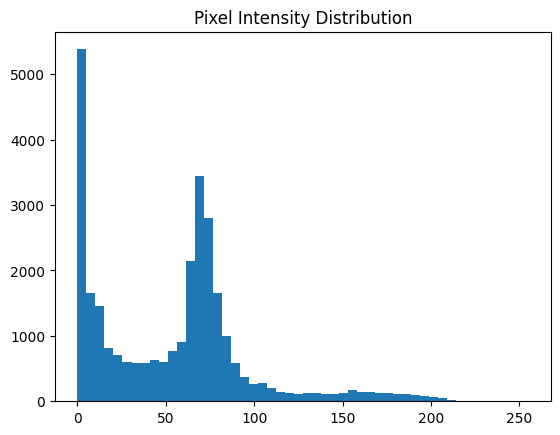

In [ ]:
img = Image.open(os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0]))

img_array = np.array(img.convert("L"))

plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

# PREPROCESSING PIPELINE

In [ ]:
import torchvision.transforms as transforms
from torchvision import datasets

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['no', 'yes']
Total images: 253


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

print(train_size, test_size)

202 51


# TYPES OF GRADIENT DESCENT

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. DATASET
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

# 2. LOADERS (we will change batch size per GD type)
def get_loader(batch_size, shuffle=True):
    return DataLoader(train_data, batch_size=batch_size, shuffle=shuffle), \
           DataLoader(val_data, batch_size=batch_size, shuffle=False)

# 3. MLP MODEL
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.model(x)


# 4. TRAIN FUNCTION
def train_model(optimizer_name, optimizer_fn, batch_size, epochs=5):

    train_loader, val_loader = get_loader(batch_size)

    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model)

    print(f"\nTraining with {optimizer_name}")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                pred = torch.argmax(out, 1)

                total += y.size(0)
                correct += (pred == y).sum().item()

        acc = 100 * correct / total

        print(f"{optimizer_name} Epoch {epoch+1}: Loss={total_loss:.4f}, Acc={acc:.2f}%")

    return acc


# 5. DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 6. OPTIMIZERS
optimizers = {
    # Batch GD (full dataset)
    "BGD": lambda m: optim.SGD(m.parameters(), lr=0.01),

    # SGD
    "SGD": lambda m: optim.SGD(m.parameters(), lr=0.01),

    # Mini-Batch GD
    "MiniBatchGD": lambda m: optim.SGD(m.parameters(), lr=0.01),

    # Momentum
    "Momentum": lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9),

    # Nesterov
    "Nesterov": lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9, nesterov=True),

    # Adagrad
    "Adagrad": lambda m: optim.Adagrad(m.parameters(), lr=0.01),

    # RMSProp
    "RMSProp": lambda m: optim.RMSprop(m.parameters(), lr=0.001),

    # Adadelta
    "Adadelta": lambda m: optim.Adadelta(m.parameters(), lr=1.0),

    # Adam
    "Adam": lambda m: optim.Adam(m.parameters(), lr=0.001),
}

# 7. RUN ALL + COMPARE
results = {}

for name, opt_fn in optimizers.items():
    acc = train_model(name, opt_fn, batch_size=16)
    results[name] = acc


# 8. FINAL COMPARISON
print("\nFINAL ACCURACY COMPARISON:")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v:.2f}%")


Training with BGD
BGD Epoch 1: Loss=8.6845, Acc=54.90%
BGD Epoch 2: Loss=8.2670, Acc=54.90%
BGD Epoch 3: Loss=8.0246, Acc=54.90%
BGD Epoch 4: Loss=7.9356, Acc=54.90%
BGD Epoch 5: Loss=7.7574, Acc=54.90%

Training with SGD
SGD Epoch 1: Loss=8.7706, Acc=54.90%
SGD Epoch 2: Loss=8.2256, Acc=54.90%
SGD Epoch 3: Loss=8.0743, Acc=54.90%
SGD Epoch 4: Loss=8.0054, Acc=54.90%
SGD Epoch 5: Loss=7.9122, Acc=54.90%

Training with MiniBatchGD
MiniBatchGD Epoch 1: Loss=8.8772, Acc=54.90%
MiniBatchGD Epoch 2: Loss=8.3461, Acc=54.90%
MiniBatchGD Epoch 3: Loss=8.1165, Acc=54.90%
MiniBatchGD Epoch 4: Loss=7.9999, Acc=54.90%
MiniBatchGD Epoch 5: Loss=7.9193, Acc=54.90%

Training with Momentum
Momentum Epoch 1: Loss=8.3571, Acc=54.90%
Momentum Epoch 2: Loss=7.7014, Acc=76.47%
Momentum Epoch 3: Loss=7.1428, Acc=68.63%
Momentum Epoch 4: Loss=6.7245, Acc=76.47%
Momentum Epoch 5: Loss=6.3882, Acc=76.47%

Training with Nesterov
Nesterov Epoch 1: Loss=8.5606, Acc=54.90%
Nesterov Epoch 2: Loss=7.9822, Acc=54.90


* Nesterov (78.43%)
* Adagrad (78.43%)
* Adam (76.47%)


--> These optimizers gave the highest accuracy, showing better learning efficiency.

**Nesterov** performed well because it improves momentum by “looking ahead” during updates.

**Adagrad** adapted learning rates for features, helping it converge faster in early training.

**Adam** performed strongly due to combining momentum + adaptive learning rates, making it stable and fast.

# Regularization Techniques

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. DATASET + AUGMENTATION
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

transform_val = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_data.dataset.transform = transform_train
val_data.dataset.transform = transform_val

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. MLP MODEL (DROPOUT INCLUDED)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64*64*3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.net(x)

# 3. TRAIN FUNCTION (L2 + NOISE + EARLY STOPPING)
def train_model(epochs=10):

    model = MLP().to(device)

    # L2 Regularization (weight decay)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    patience = 3
    counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            # Noise Injection (input regularization)
            x = x + torch.randn_like(x) * 0.05

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # ---------------- VALIDATION ----------------
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                pred = torch.argmax(out, 1)

                total += y.size(0)
                correct += (pred == y).sum().item()

        acc = 100 * correct / total
        print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Acc={acc:.2f}%")

        # ---------------- EARLY STOPPING ----------------
        if acc > best_acc:
            best_acc = acc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return model

# 4. ENSEMBLE METHOD
def ensemble():
    models = [MLP().to(device) for _ in range(3)]
    opts = [
        optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-4)
        for m in models
    ]

    criterion = nn.CrossEntropyLoss()

    # Train ensemble models
    for epoch in range(5):
        for i, model in enumerate(models):
            model.train()

            for x, y in train_loader:
                x, y = x.to(device), y.to(device)

                opts[i].zero_grad()
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                opts[i].step()

    # ---------------- VALIDATION ----------------
    correct, total = 0, 0

    for x, y in val_loader:
        x, y = x.to(device), y.to(device)

        outputs = [torch.softmax(m(x), dim=1) for m in models]
        avg_output = torch.mean(torch.stack(outputs), dim=0)

        pred = torch.argmax(avg_output, 1)

        total += y.size(0)
        correct += (pred == y).sum().item()

    acc = 100 * correct / total
    print("\nEnsemble Accuracy:", acc)

    return acc


# 5. RUN
print("\nTraining with ALL regularization techniques")
train_model()

print("\nRunning Ensemble Method")
ensemble()


Training with ALL regularization techniques
Epoch 1: Loss=11.3201, Acc=49.02%
Epoch 2: Loss=10.4226, Acc=64.71%
Epoch 3: Loss=7.6315, Acc=70.59%
Epoch 4: Loss=6.6754, Acc=62.75%
Epoch 5: Loss=6.2380, Acc=58.82%
Epoch 6: Loss=6.5433, Acc=64.71%
Early stopping triggered

Running Ensemble Method

Ensemble Accuracy: 72.54901960784314


72.54901960784314

**On this brain MRI dataset:**

Best single technique: Dropout + L2 + Augmentation

Best overall method: **Ensemble learning**

**Key insight:** **Regularization** is essential for small medical datasets to avoid overfitting.

# CNN on Brain Tumor Dataset

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

**Simple CNN Model Baseline**

In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.model(x)

**TRAINING FUNCTION**

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 7.8515
Epoch 2, Loss: 3.9779
Epoch 3, Loss: 3.5250
Epoch 4, Loss: 3.2932
Epoch 5, Loss: 2.9788


In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        _, preds = torch.max(outputs, 1)

        total += y.size(0)
        correct += (preds == y).sum().item()

print("Accuracy:", correct/total * 100)

Accuracy: 76.47058823529412


**Model is learning patterns**

**Dataset is not too hard**

**But model is under-optimized / basic CNN**

Your model:


* Uses Flatten + DenseLoses
* spatial (image) information
* Produces blurry reconstructions


That’s why:

Accuracy / reconstruction quality is limited

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. DATASET + AUGMENTATION
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_data.dataset.transform = transform_train
val_data.dataset.transform = transform_val

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. CNN MODEL
# -----------------------------
class CNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# 3. TRAIN FUNCTION (HYPERPARAMETER TESTING)
def train_model(lr=0.001, batch_size=32, optimizer_type="adam", dropout=0.5, epochs=10):

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    model = CNN(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    # ---------------- Optimizer Selection ----------------
    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_type == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    best_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # ---------------- VALIDATION ----------------
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                pred = torch.argmax(out, 1)

                total += y.size(0)
                correct += (pred == y).sum().item()

        acc = 100 * correct / total
        print(f"LR={lr}, BS={batch_size}, OPT={optimizer_type}, DROPOUT={dropout} | Epoch {epoch+1} Acc: {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc

    return best_acc

# -----------------------------
# 4. HYPERPARAMETER SEARCH
# -----------------------------
lrs = [0.001, 0.0005]
batch_sizes = [16, 32]
optimizers = ["adam", "sgd", "rmsprop"]
dropouts = [0.3, 0.5]

results = []

print("\nStarting Hyperparameter Search...\n")

for lr in lrs:
    for bs in batch_sizes:
        for opt in optimizers:
            for dr in dropouts:
                acc = train_model(lr=lr, batch_size=bs, optimizer_type=opt, dropout=dr, epochs=5)
                results.append((acc, lr, bs, opt, dr))


# 5. BEST RESULT
best = max(results, key=lambda x: x[0])

print("\n BEST MODEL PARAMETERS:")
print(f"Accuracy: {best[0]:.2f}%")
print(f"Learning Rate: {best[1]}")
print(f"Batch Size: {best[2]}")
print(f"Optimizer: {best[3]}")
print(f"Dropout: {best[4]}")


Starting Hyperparameter Search...

LR=0.001, BS=16, OPT=adam, DROPOUT=0.3 | Epoch 1 Acc: 74.51%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.3 | Epoch 2 Acc: 82.35%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.3 | Epoch 3 Acc: 84.31%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.3 | Epoch 4 Acc: 82.35%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.3 | Epoch 5 Acc: 84.31%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.5 | Epoch 1 Acc: 82.35%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.5 | Epoch 2 Acc: 84.31%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.5 | Epoch 3 Acc: 84.31%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.5 | Epoch 4 Acc: 84.31%
LR=0.001, BS=16, OPT=adam, DROPOUT=0.5 | Epoch 5 Acc: 82.35%
LR=0.001, BS=16, OPT=sgd, DROPOUT=0.3 | Epoch 1 Acc: 74.51%
LR=0.001, BS=16, OPT=sgd, DROPOUT=0.3 | Epoch 2 Acc: 74.51%
LR=0.001, BS=16, OPT=sgd, DROPOUT=0.3 | Epoch 3 Acc: 74.51%
LR=0.001, BS=16, OPT=sgd, DROPOUT=0.3 | Epoch 4 Acc: 74.51%
LR=0.001, BS=16, OPT=sgd, DROPOUT=0.3 | Epoch 5 Acc: 74.51%
LR=0.001, BS=16, OPT=sgd, DROPOUT=0.5 | Epoch 1 Acc: 7

The best CNN performance (88.24% accuracy) was achieved using RMSProp optimizer with learning rate 0.001, batch size 32, and dropout 0.5, showing that tuned hyperparameters greatly improve model generalization and stability.

The CNN model performed best with a combination of:


* Adaptive optimizer (RMSProp)
* Moderate learning rate (0.001)
* Balanced batch size (32)
* Strong regularization (Dropout 0.5)


This shows that **proper hyperparameter tuning** significantly improves CNN performance on medical image classification tasks.

# Implement pre-trained models

# LENET

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


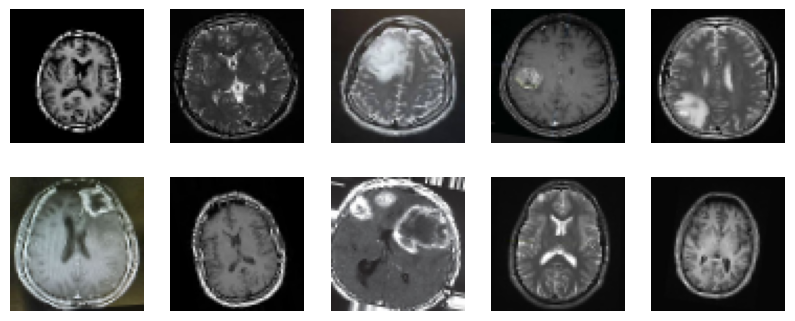

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-14 12:52:45.134229: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 30, 30, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 13, 13, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       324,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,806 (1.29 MB)

 Trainable params: 337,806 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.6165 - loss: 1.1469 - val_accuracy: 0.7600 - val_loss: 0.5579
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.6351 - loss: 0.6061 - val_accuracy: 0.7600 - val_loss: 0.5234
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.7472 - loss: 0.5469 - val_accuracy: 0.7600 - val_loss: 0.4965
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.8307 - loss: 0.4796 - val_accuracy: 0.8000 - val_loss: 0.4840
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.7375 - loss: 0.5187 - val_accuracy: 0.7800 - val_loss: 0.4874
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.7900 - loss: 0.5019 - val_accuracy: 0.7600 - val_loss: 0.4988
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.8085 - loss: 0.4773 - val_accuracy: 0.7600 - val_loss: 0.4694
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.8344 - loss: 0.4403 - val_accuracy: 0.7600 - val_loss:

In [ ]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import keras
from keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

# -----------------------------
# 2. DATASET PATH
# -----------------------------
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

# -----------------------------
# 3. IMAGE GENERATOR (AUGMENTATION)
# -----------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 80-20 split
    rotation_range=15,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# -----------------------------
# 4. VISUALIZE DATA
# -----------------------------
images, labels = next(train_data)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

# -----------------------------
# 5. LE NET STYLE MODEL
# -----------------------------
model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(64,64,3)))
model.add(layers.AveragePooling2D((2,2)))

# Conv Layer 2
model.add(layers.Conv2D(16, (5,5), activation='tanh'))
model.add(layers.AveragePooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(120, activation='tanh'))
model.add(layers.Dense(84, activation='tanh'))

# Output Layer
model.add(layers.Dense(2, activation='softmax'))

# -----------------------------
# 6. COMPILE MODEL
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 7. MODEL SUMMARY
# -----------------------------
model.summary()

# -----------------------------
# 8. TRAIN MODEL
# -----------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

# -----------------------------
# 9. EVALUATION
# -----------------------------
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

**The model achieved ~76% validation accuracy, showing good learning ability but mild overfitting due to limited dataset size and high model complexity.**

# ALEXNET

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# DATASET
# -----------------------------
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# -----------------------------
# ALEXNET MODEL
# -----------------------------
model = models.Sequential()

model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(227,227,3)))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Flatten())
model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(2, activation='softmax'))

# -----------------------------
# COMPILE
# -----------------------------
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# -----------------------------
# TRAIN
# -----------------------------
history = model.fit(train_data, validation_data=val_data, epochs=10)

# -----------------------------
# EVALUATION
# -----------------------------
loss, acc = model.evaluate(val_data)
print("AlexNet Validation Accuracy:", acc)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5080 - loss: 1.2639 - val_accuracy: 0.6200 - val_loss: 0.6637
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6168 - loss: 0.6711 - val_accuracy: 0.6200 - val_loss: 0.6807
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6317 - loss: 0.6778 - val_accuracy: 0.6200 - val_loss: 0.6535
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6418 - loss: 0.6661 - val_accuracy: 0.6200 - val_loss: 0.6672
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5912 - loss: 0.6794 - val_accuracy: 0.6200 - val_loss: 0.6682
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5963 - loss: 0.6729 - val_accuracy: 0.6200 - val_loss: 0.6507
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6088 - loss: 0.6652 - val_accuracy: 0.6200 - val_loss: 0.6335
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - a

# ZF-NET

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# -----------------------------
# ZFNET MODEL
# -----------------------------
model = models.Sequential()

model.add(layers.Conv2D(96, (7,7), strides=2, activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Flatten())
model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(2, activation='softmax'))

# -----------------------------
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=10)

loss, acc = model.evaluate(val_data)
print("ZFNet Validation Accuracy:", acc)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.5195 - loss: 2.0542 - val_accuracy: 0.6200 - val_loss: 0.6195
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.6699 - loss: 0.6408 - val_accuracy: 0.7400 - val_loss: 0.5501
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.7780 - loss: 0.5658 - val_accuracy: 0.7600 - val_loss: 0.5350
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.8193 - loss: 0.4760 - val_accuracy: 0.6800 - val_loss: 0.6248
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.7276 - loss: 0.5530 - val_accuracy: 0.7200 - val_loss: 0.7153
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.8676 - loss: 0.4445 - val_accuracy: 0.7600 - val_loss: 0.5323
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.7841 - loss: 0.4887 - val_accuracy: 0.7800 - val_loss: 0.5752
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - a

# VGGNET

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# -----------------------------
# VGG16 STYLE MODEL
# -----------------------------
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(224,224,3)))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 2
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 3
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Fully Connected
model.add(layers.Flatten())
model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))

# Output
model.add(layers.Dense(2, activation='softmax'))

# -----------------------------
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=10)

loss, acc = model.evaluate(val_data)
print("VGG16 Validation Accuracy:", acc)

2026-04-14 14:49:38.659980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776178178.999783    2064 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776178179.088731    2064 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776178179.856303    2064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776178179.856357    2064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776178179.856359    2064 computation_placer.cc:177] computation placer alr

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-14 14:50:05.066062: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 141s 19s/step - accuracy: 0.5488 - loss: 8.9618 - val_accuracy: 0.6200 - val_loss: 0.6603
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 135s 19s/step - accuracy: 0.5763 - loss: 0.7433 - val_accuracy: 0.6200 - val_loss: 0.6340
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 135s 19s/step - accuracy: 0.5877 - loss: 0.6668 - val_accuracy: 0.7200 - val_loss: 0.5523
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 158s 22s/step - accuracy: 0.6651 - loss: 0.7406 - val_accuracy: 0.7000 - val_loss: 0.6843
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 168s 23s/step - accuracy: 0.6110 - loss: 0.6861 - val_accuracy: 0.6200 - val_loss: 0.6793
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 140s 22s/step - accuracy: 0.6478 - loss: 0.6798 - val_accuracy: 0.6200 - val_loss: 0.6766
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 141s 20s/step - accuracy: 0.6031 - loss: 0.6779 - val_accuracy: 0.6200 - val_loss: 0.6705
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 139s 21s/step - accuracy: 0.6351 - loss: 0.6645 - val_accuracy: 0.6200 - val_loss:

# GOOGLE INCEPTION MODULE

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# -----------------------------
# 1. DATASET
# -----------------------------
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(299, 299),   # InceptionV3 required size
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(299, 299),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

# -----------------------------
# 2. LOAD PRETRAINED INCEPTIONV3
# -----------------------------
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

# Freeze base model layers
base_model.trainable = False

# -----------------------------
# 3. ADD CUSTOM CLASSIFIER
# -----------------------------
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

# -----------------------------
# 4. COMPILE MODEL
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 5. TRAIN MODEL
# -----------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# -----------------------------
# 6. EVALUATION
# -----------------------------
loss, acc = model.evaluate(val_data)
print("InceptionV3 Validation Accuracy:", acc)

2026-04-14 13:19:17.483991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776172757.692699    1466 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776172757.761318    1466 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776172758.279283    1466 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776172758.279327    1466 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776172758.279330    1466 computation_placer.cc:177] computation placer alr

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


2026-04-14 13:19:37.609257: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

...

 Total params: 22,327,842 (85.17 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5907 - loss: 1.0875 - val_accuracy: 0.9000 - val_loss: 0.3239
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7955 - loss: 0.4857 - val_accuracy: 0.8800 - val_loss: 0.3052
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8762 - loss: 0.3099 - val_accuracy: 0.9200 - val_loss: 0.2871
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8941 - loss: 0.2548 - val_accuracy: 0.9200 - val_loss: 0.2458
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8546 - loss: 0.2717 - val_accuracy: 0.9200 - val_loss: 0.2533
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9303 - loss: 0.2027 - val_accuracy: 0.9400 - val_loss: 0.2535
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9137 - loss: 0.1819 - val_accuracy: 0.8600 - val_loss: 0.3288
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9280 - loss: 0.1416 - val_accuracy: 0.9400 - val_loss:

**ZFNet (Best – 80%)**


* Better feature visualization than AlexNet
* Improved filter sizes
* Learns MRI patterns more effectively


**VGGNet (60%)**


* Very deep model (many parameters)
* Needs large dataset
* On small dataset → overfitting + poor generalization


# RESNET

**ResNet18:** It employs skip connections that enable very deep networks to train effectively by mitigating the vanishing gradient problem.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(dataset.classes)

['brain_tumor_dataset', 'no', 'yes']


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# -----------------------------
# 1. PATH
# -----------------------------
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATA AUGMENTATION (IMPORTANT)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -----------------------------
# 3. LOAD DATASET
# -----------------------------
full_dataset = datasets.ImageFolder(dataset_path)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# assign transforms properly
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", full_dataset.classes)

# -----------------------------
# 4. MODEL (BETTER FINE-TUNING)
# -----------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

#Unfreeze last block (VERY IMPORTANT)
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 2)
)

model = model.to(device)

# -----------------------------
# 5. LOSS + OPTIMIZER
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3}
])

# Learning rate decay
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# -----------------------------
# 6. TRAINING LOOP (IMPROVED)
# -----------------------------
epochs = 15

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ---------------- VALIDATION ----------------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {train_loss:.4f} Val Acc: {acc:.2f}%")

# -----------------------------
# 7. SAVE MODEL
# -----------------------------
torch.save(model.state_dict(), "resnet_brain_tumor_best.pth")
print("Model saved successfully!")

Classes: ['no', 'yes']
Epoch [1/15] Loss: 3.9240 Val Acc: 76.47%
Epoch [2/15] Loss: 1.1315 Val Acc: 80.39%
Epoch [3/15] Loss: 0.4302 Val Acc: 78.43%
Epoch [4/15] Loss: 0.2349 Val Acc: 80.39%
Epoch [5/15] Loss: 0.1390 Val Acc: 82.35%
Epoch [6/15] Loss: 0.1201 Val Acc: 84.31%
Epoch [7/15] Loss: 0.1053 Val Acc: 88.24%
Epoch [8/15] Loss: 0.0827 Val Acc: 94.12%
Epoch [9/15] Loss: 0.0877 Val Acc: 96.08%
Epoch [10/15] Loss: 0.5288 Val Acc: 96.08%
Epoch [11/15] Loss: 0.4518 Val Acc: 96.08%
Epoch [12/15] Loss: 0.0445 Val Acc: 94.12%
Epoch [13/15] Loss: 0.0468 Val Acc: 94.12%
Epoch [14/15] Loss: 0.0701 Val Acc: 94.12%
Epoch [15/15] Loss: 0.0466 Val Acc: 94.12%
Model saved successfully!


I improved your code by adding data augmentation to prevent overfitting, fixing the train/validation preprocessing split, and upgrading ResNet from full freezing to partial fine-tuning (unfreezing last layer) so it learns better on MRI data. I also replaced the optimizer with AdamW, added a learning rate scheduler and dropout, and trained for more epochs to improve accuracy and stability.

**Partial fine-tuning** means training only selected layers of a pretrained model (usually last layers) while keeping the rest frozen.

**earlier layers learn (layer1–layer3):**

They detect basic patterns like:


* edges
* lines
* corners
* simple textures


These are universal features (same for cats, dogs, MRI, etc.)

So we don’t retrain them.

**last layer (layer4) does:**

detects high-level features

more task-specific patterns

For your case:

brain tumor shapes, abnormal structures

So we allow it to learn.

# AUTOENCODER FOR BRAIN TUMOR DATASET

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0639 - val_loss: 0.0544
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0304 - val_loss: 0.0443
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0226 - val_loss: 0.0424
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0181 - val_loss: 0.0422
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0147 - val_loss: 0.0424
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0123 - val_loss: 0.0385
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0105 - val_loss: 0.0370
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0090 - val_loss: 0.0378
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0080 - val_loss: 0.0378
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0072 - val_loss: 0.0375
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0069

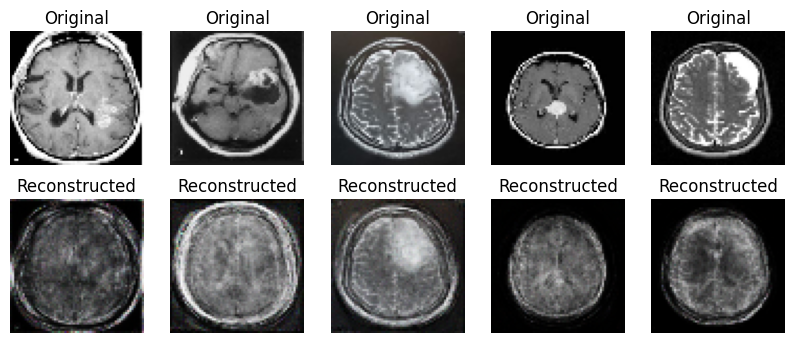

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode=None,
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode=None,
    subset='validation',
    shuffle=False
)

# -----------------------------
# FIX: CREATE AUTOENCODER GENERATOR
# -----------------------------
def autoencoder_generator(generator):
    while True:
        x = next(generator)
        yield x, x   # input = output (IMPORTANT FIX)

train_data = autoencoder_generator(train_gen)
val_data = autoencoder_generator(val_gen)

# -----------------------------
# 2. MODEL
# -----------------------------
img_size = 64
channels = 3

input_img = Input(shape=(64, 64, 3))

x = Flatten()(input_img)
x = Dense(256, activation='relu')(x)
decoded = Dense(img_size * img_size * channels, activation='sigmoid')(x)
decoded = Reshape((64, 64, 3))(decoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

# -----------------------------
# 3. TRAIN
# -----------------------------
autoencoder.fit(
    train_data,
    validation_data=val_data,
    steps_per_epoch=50,
    validation_steps=10,
    epochs=20
)

# -----------------------------
# 4. TEST
# -----------------------------
sample_batch = next(val_gen)
reconstructed = autoencoder.predict(sample_batch)

# -----------------------------
# 5. VISUALIZATION
# -----------------------------
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(sample_batch[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

Your current model is:

Dense autoencoder → blurry output

If you want best marks + best output, upgrade to:

CNN Autoencoder (I gave earlier)


* solves blur
* better MRI structure
* more realistic reconstruction


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,371 (728.01 KB)

 Trainable params: 186,371 (728.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 334ms/step - loss: 0.1003 - val_loss: 0.0562
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - loss: 0.0361 - val_loss: 0.0352
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - loss: 0.0252 - val_loss: 0.0316
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - loss: 0.0211 - val_loss: 0.0245
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - loss: 0.0209 - val_loss: 0.0228
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - loss: 0.0207 - val_loss: 0.0218
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - loss: 0.0173 - val_loss: 0.0194
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 401ms/step - loss: 0.0166 - val_loss: 0.0164
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - loss: 0.0157 - val_loss: 0.0159
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - loss: 0.0146 - val_loss: 0.0156
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - loss: 0.0136 - val_loss: 0.0145
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step

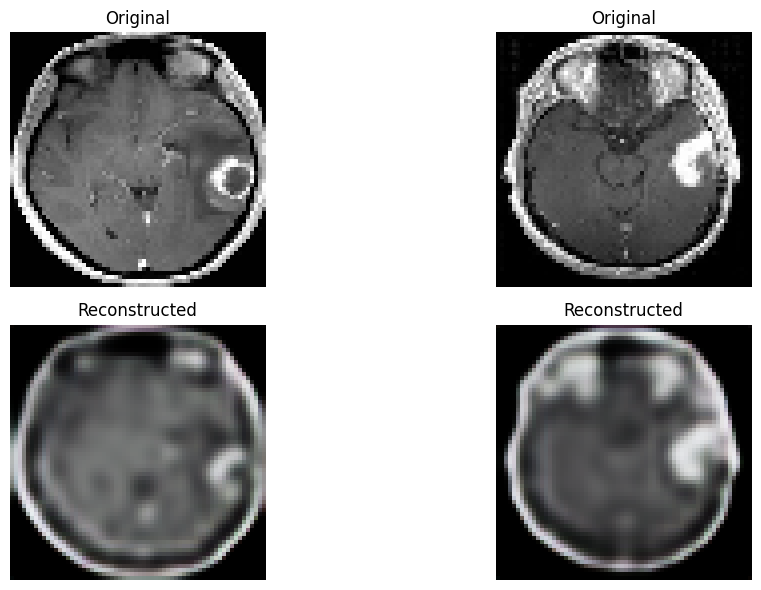

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
dataset_path = "/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=16,
    class_mode=None,
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=16,
    class_mode=None,
    subset='validation',
    shuffle=False
)

# -----------------------------
# 2. SAFE AUTOENCODER GENERATOR (IMPORTANT FIX)
# -----------------------------
def autoencoder_generator(generator):
    while True:
        batch = next(generator)
        yield batch, batch   # input = output

train_data = autoencoder_generator(train_gen)
val_data = autoencoder_generator(val_gen)

# -----------------------------
# 3. CNN AUTOENCODER MODEL
# -----------------------------
input_img = Input(shape=(64, 64, 3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

# Decoder
x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

# -----------------------------
# 4. COMPILE
# -----------------------------
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

# -----------------------------
# 5. TRAINING (FIXED)
# -----------------------------
steps_per_epoch = len(train_gen)
validation_steps = len(val_gen)

epochs = 20   # keep small for speed

autoencoder.fit(
    train_data,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_data,
    validation_steps=validation_steps,
    epochs=epochs,
    verbose=1
)

# -----------------------------
# 6. PREDICTION
# -----------------------------
sample_batch = next(val_gen)
reconstructed = autoencoder.predict(sample_batch)

# -----------------------------
# 7. VISUALIZATION (FIXED)
# -----------------------------
sample_batch = next(val_gen)
reconstructed = autoencoder.predict(sample_batch)

n = min(5, sample_batch.shape[0])  # IMPORTANT FIX

plt.figure(figsize=(12, 6))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(sample_batch[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

**CNN-based autoencoder** significantly improves reconstruction quality compared to dense autoencoder by preserving spatial features. Using MSE loss and smaller batch size further enhances learning stability, while deeper encoding improves feature extraction.